In [2]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
g=9.81
Ts=0.005


In [3]:
class X():
    def __init__(self,state=np.zeros(6)):
        self.x,self.y,self.phi=state[0],state[1],state[2]
        self.xDot,self.yDot,self.phiDot=state[3],state[4],state[5]
    def __call__(self):
        return [self.x,self.y,self.phi,self.xDot,self.yDot,self.phiDot]


class Obstacle:
    def __init__(self,x,y,r):
        self.c=np.array([x,y])
        self.r=r
    def CheckCollisionThroughTime(self,state):
        nChecks=state.shape[1]
        for i in range(nChecks):
            currentState=X(state[:,i])
            if self.CheckCollision([currentState.x,currentState.y]):
                return 1
        return 0
    def CheckCollision(self,point,offset=0):
        distance=np.linalg.norm(np.array(point-self.c))
        if distance<=(self.r+offset):
            return 1
    def __call__(self):
        return self.c,self.r
    



In [4]:
class DynamicObstacle:
    def __init__(self, x, y, r, vx=0.0, vy=0.0):
        self.c = np.array([float(x), float(y)])
        self.r = r
        self.v = np.array([float(vx), float(vy)])
        
    def update(self, dt, x_bounds=(0, 800), y_bounds=(0, 450)):
        self.c += self.v * dt
        
        if self.c[0] - self.r <= x_bounds[0] or self.c[0] + self.r >= x_bounds[1]:
            self.v[0] *= -1
        if self.c[1] - self.r <= y_bounds[0] or self.c[1] + self.r >= y_bounds[1]:
            self.v[1] *= -1

    def __call__(self):
        return self.c, self.r
    
    


In [5]:
from scipy.integrate import solve_ivp
goalWidth=20
XLim=800
floor=0
cieling=450

class Quadcopter:
    def __init__(self, m=0.18, L=0.086, J=1.5e-4):
        self.m, self.L, self.J = m, L, J
        self.g = 9.81
        self.cd = 0.05 
        self.state = X()

    def step(self, action, dt, wind_force=np.array([0.0, 0.0])):
        u = np.clip(action, -1, 1)
        F = ((u[0] + 1)/2) * (1.8 * self.m * self.g)
        M = u[1] * 0.02

        s = np.array([self.state.x, self.state.y, self.state.phi, 
                      self.state.xDot, self.state.yDot, self.state.phiDot])
        
        def f(st, f_val, m_val):
            return np.array([
                st[3], st[4], st[5],
                -(f_val/self.m)*np.sin(st[2]) - (self.cd/self.m)*st[3] + (wind_force[0]/self.m),
                (f_val/self.m)*np.cos(st[2]) - self.g - (self.cd/self.m)*st[4] + (wind_force[1]/self.m),
                m_val/self.J
            ])

        k1 = f(s, F, M)
        k2 = f(s + 0.5*dt*k1, F, M)
        k3 = f(s + 0.5*dt*k2, F, M)
        k4 = f(s + dt*k3, F, M)
        
        self.state = X(s + (dt/6)*(k1 + 2*k2 + 2*k3 + k4))


In [ ]:
from cvxopt import matrix,solvers

solvers.options['show_progress']=False

class Sigma:
    def __init__(self, k=0.02, limit=100.0):
        self.k = k
        self.limit = limit
    def val(self, s):
        return self.limit * np.tanh(self.k * s)
    def prime(self, s):
        return self.limit * self.k * (1 - np.tanh(self.k * s)**2)
    def dPrime(self, s):
        tanh_s = np.tanh(self.k * s)
        return -2 * self.limit * (self.k**2) * tanh_s * (1 - tanh_s**2)

class CBFQPController:
    def __init__(self, nominal_controller, m, J, gamma=0.8, alpha=0.8):
        self.nominal = nominal_controller 
        self.m = m
        self.J = J
        self.gamma = gamma # Lookahead horizon
        self.alpha = alpha 
        self.sigma = Sigma() 

    def cbfConstraint(self, state, lidar_dists, lidar_angles):
        G_obs, H_obs = [], []
        rSafe = 10
        
        activation_dist = 100 
        
        for dist, angle in zip(lidar_dists, lidar_angles):
            if dist >= activation_dist:
                continue 
                
            rx = -dist * np.cos(angle)
            ry = -dist * np.sin(angle)
            
            s = rx * np.sin(state.phi) - ry * np.cos(state.phi)
            p = rx * np.cos(state.phi) + ry * np.sin(state.phi)
            
            v = -state.xDot * np.sin(state.phi) + state.yDot * np.cos(state.phi)
            w =  state.xDot * np.cos(state.phi) + state.yDot * np.sin(state.phi)
            
            ds = -v + p * state.phiDot 
            
            h = (rx**2 + ry**2) - rSafe**2
            hDot = 2 * (rx * state.xDot + ry * state.yDot)
            
            sig = self.sigma.val(s)
            sigP = self.sigma.prime(s)
            sigPP = self.sigma.dPrime(s)
            
            gHat = h - sig
            gHatDot = hDot - sigP * ds
            hAug = gHatDot + self.gamma * gHat
            
            C_drift = 2 * (state.xDot**2 + state.yDot**2) - 2 * 9.81 * ry
            C_sig = -sigPP * (ds**2) - sigP * (9.81 * np.cos(state.phi) + 2 * w * state.phiDot + s * (state.phiDot**2))
            C = C_drift + C_sig + self.gamma * gHatDot
            
            Lg1 = -(1 / self.m) * (2 * s - sigP)
            Lg2 = -(p * sigP) / self.J
            
            G_obs.append([-Lg1, -Lg2])
            H_obs.append(C + self.alpha * hAug)
            
        G_bounds, H_bounds = [], []
        
        # Floor
        y_floor =15
        h_floor = state.y - y_floor
        Lg_floor = [-np.cos(state.phi) / self.m, 0]
        gamma_floor=0.8
        boundary_floor = -9.81 + 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_floor
        G_bounds.append(Lg_floor)
        H_bounds.append(boundary_floor)
            
        # Ceiling
        y_ceil = 445
        h_ceil = y_ceil - state.y
        Lg_ceil = [np.cos(state.phi) / self.m, 0]
        boundary_ceil = 9.81 - 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_ceil
        G_bounds.append(Lg_ceil)
        H_bounds.append(boundary_ceil)

        return np.array(G_obs), np.array(H_obs), np.array(G_bounds), np.array(H_bounds)

    def filter_action(self, u_nom, state, lidar_dists, lidar_angles):
        P = matrix(np.diag([1, 1, 1e7])) 
        q = matrix([-u_nom[0], -u_nom[1], 0])
        
        G_obs, h_obs, G_bounds, h_bounds = self.cbfConstraint(state, lidar_dists, lidar_angles)
        
        max_thrust = 1.8 * self.m * 9.81
        max_moment = 0.02
        u_max = np.array([max_thrust, max_moment])
        u_min = np.array([0, -max_moment])
        
        G_sat = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])
        h_sat = np.array([u_max[0], -u_min[0], u_max[1], -u_min[1]])

        if len(G_obs) > 0:
            slack_col = -np.ones((len(G_obs), 1))
            G_obs_cbf = np.hstack([G_obs, slack_col])
            
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_obs_cbf, G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_obs, h_bounds, h_sat]).astype(np.float64))
        else:
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_bounds, h_sat]).astype(np.float64))

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            if sol['status'] != 'optimal':
                raise ValueError("QP not optimal")
            slack_vals = np.array(sol['x']).flatten()[2:]
            if len(slack_vals) > 0 and np.max(slack_vals) > 5.0:
                raise ValueError("Constraint conflict - Slack threshold exceeded")
                print("slack bypassed")
            u_safe = np.array(sol['x']).flatten()[:2]
            return u_safe
            
        except Exception:
            target_phi = 0
            M_fallback = 1.2 * (target_phi - state.phi) - 0.3 * state.phiDot
            M_fallback = np.clip(M_fallback, -max_moment, max_moment)
            if state.y < 50:
                F_fallback = max_thrust
            elif state.y > 400:
                F_fallback = 0
            else:
                F_fallback = self.m * 9.81
            return np.array([F_fallback, M_fallback])


In [ ]:
from cvxopt import matrix, solvers
import numpy as np

solvers.options['show_progress'] = False

class LocalAdaptiveCBFQPController:
    def __init__(self, m_nom=0.18, J=1.5e-4, gamma=0.6, alpha=0.6):
        self.J = J
        self.gamma = gamma 
        self.alpha = alpha 
        self.sigma = Sigma() 
        
        self.theta_m = 1/ m_nom  
        self.d_x = 0              
        self.d_y = 0
        self.theta_cd = 0 
        
        self.Gamma_m = 0.2
        self.Gamma_cd = 0.02
        self.Gamma_w = 0.05

        self.Gamma_m = 0.5
        self.Gamma_w = 0.16
        self.Gamma_cd = 0.02 

        
        self.theta_min = 1/ 0.4 
        self.theta_max = 1/ 0.10  
        self.wind_max = 15 
        self.cd_max = 2        

    def cbfConstraint(self, state, lidar_dists, lidar_angles):
        G_obs, H_obs = [], []
        rSafe = 10 
        activation_dist = 150 
        
        for dist, angle in zip(lidar_dists, lidar_angles):
            if dist >= activation_dist:
                continue 
                
            rx = -dist * np.cos(angle)
            ry = -dist * np.sin(angle)
            
            s = rx * np.sin(state.phi) - ry * np.cos(state.phi)
            p = rx * np.cos(state.phi) + ry * np.sin(state.phi)
            
            v = -state.xDot * np.sin(state.phi) + state.yDot * np.cos(state.phi)
            w =  state.xDot * np.cos(state.phi) + state.yDot * np.sin(state.phi)
            
            ds = -v + p * state.phiDot 
            
            h = (rx**2 + ry**2) - rSafe**2
            hDot = 2 * (rx * state.xDot + ry * state.yDot)
            
            sig = self.sigma.val(s)
            sigP = self.sigma.prime(s)
            sigPP = self.sigma.dPrime(s)
            
            gHat = h - sig
            gHatDot = hDot - sigP * ds
            hAug = gHatDot + self.gamma * gHat

            C_drift = 2 * (state.xDot**2 + state.yDot**2) - 2 * 9.81 * ry
            C_sig = -sigPP * (ds**2) - sigP * (9.81 * np.cos(state.phi) + 2 * w * state.phiDot + s * (state.phiDot**2))
            
            total_dist_x = self.d_x - self.theta_cd * state.xDot
            total_dist_y = self.d_y - self.theta_cd * state.yDot
            
            C_dist = total_dist_x * (2 * rx + sigP * np.sin(state.phi)) + \
                     total_dist_y * (2 * ry - sigP * np.cos(state.phi))
            
            C = C_drift + C_sig + C_dist + self.gamma * gHatDot
            
            Lg1 = -self.theta_m * (2 * s - sigP)
            Lg2 = -(p * sigP) / self.J
            
            G_obs.append([-Lg1, -Lg2])
            H_obs.append(C + self.alpha * hAug)
            
        G_bounds, H_bounds = [], []
        
        # Floor
        y_floor = 15
        h_floor = state.y - y_floor
        Lg_floor = [-self.theta_m * np.cos(state.phi), 0]
        gamma_floor = 0.8
        boundary_floor = -9.81 + 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_floor
        G_bounds.append(Lg_floor)
        H_bounds.append(boundary_floor)
            
        # Ceiling
        y_ceil = 445
        h_ceil = y_ceil - state.y
        Lg_ceil = [self.theta_m * np.cos(state.phi), 0]
        boundary_ceil = 9.81 - 2 * gamma_floor * state.yDot + (gamma_floor**2) * h_ceil
        G_bounds.append(Lg_ceil)
        H_bounds.append(boundary_ceil)

        return np.array(G_obs), np.array(H_obs), np.array(G_bounds), np.array(H_bounds)

    def filter_action(self, u_nom, state, lidar_dists, lidar_angles):
        P = matrix(np.diag([1.0, 1.0, 1e7])) 
        q = matrix([-float(u_nom[0]), -float(u_nom[1]), 0.0])
        
        G_obs, h_obs, G_bounds, h_bounds = self.cbfConstraint(state, lidar_dists, lidar_angles)
        
        # Certainty Equivalence for the max thrust constraint
        max_thrust = 1.8 * (1/ self.theta_m) * 9.81 
        max_moment = 0.02
        u_max = np.array([max_thrust, max_moment])
        u_min = np.array([0, -max_moment])
        
        G_sat = np.array([[1, 0], [-1, 0], [0, 1], [0, -1]])
        h_sat = np.array([u_max[0], -u_min[0], u_max[1], -u_min[1]])

        if len(G_obs) > 0:
            slack_col = -np.ones((len(G_obs), 1))
            G_obs_cbf = np.hstack([G_obs, slack_col])
            
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_obs_cbf, G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_obs, h_bounds, h_sat]).astype(np.float64))
        else:
            no_slack_bounds = np.zeros((len(G_bounds), 1))
            G_bounds_cbf = np.hstack([G_bounds, no_slack_bounds])
            no_slack_sat = np.zeros((4, 1))
            G_sat_cbf = np.hstack([G_sat, no_slack_sat])
            
            G_final = matrix(np.vstack([G_bounds_cbf, G_sat_cbf]).astype(np.float64))
            h_final = matrix(np.hstack([h_bounds, h_sat]).astype(np.float64))

        try:
            sol = solvers.qp(P, q, G_final, h_final)
            if sol['status'] != 'optimal': raise ValueError("QP not optimal")
            
            slack_vals = np.array(sol['x']).flatten()[2:]
            if len(slack_vals) > 0 and np.max(slack_vals) > 5.0:
                raise ValueError("Constraint conflict - Slack threshold exceeded")
                
            return np.array(sol['x']).flatten()[:2]
        except Exception:
            target_phi = 0
            M_fallback = 1.2 * (target_phi - state.phi) - 0.3 * state.phiDot
            M_fallback = np.clip(M_fallback, -max_moment, max_moment)
            if state.y < 50:
                F_fallback = max_thrust
            elif state.y > 400:
                F_fallback = 0
            else:
                F_fallback = (1/ self.theta_m) * 9.81
            return np.array([F_fallback, M_fallback])

    def adapt(self, phi, u1_applied, true_ax, true_ay, dt, vx, vy):        
        expected_ax = -self.theta_m * u1_applied * np.sin(phi) + self.d_x - self.theta_cd * vx
        expected_ay =  self.theta_m * u1_applied * np.cos(phi) - 9.81 + self.d_y - self.theta_cd * vy
        
        error_ax = true_ax - expected_ax
        error_ay = true_ay - expected_ay
        
        grad_theta_m = error_ay * (u1_applied * np.cos(phi)) 
        grad_dx = error_ax
        grad_dy = error_ay
        
        grad_theta_cd = error_ax * (-vx) + error_ay * (-vy)
        
        self.theta_m += (self.Gamma_m) * grad_theta_m * dt
        self.theta_m = np.clip(self.theta_m, self.theta_min, self.theta_max)
        
        self.d_x += (self.Gamma_w) * grad_dx * dt
        self.d_x = np.clip(self.d_x, -self.wind_max, self.wind_max)
        
        self.d_y += (self.Gamma_w) * grad_dy * dt
        self.d_y = np.clip(self.d_y, -self.wind_max, self.wind_max)
        
        self.theta_cd += (self.Gamma_cd) * grad_theta_cd * dt
        self.theta_cd = np.clip(self.theta_cd, 0.0, self.cd_max)


In [8]:
import control

class GoalVectorField:
    def __init__(self, goal, goalWidth=20, maxSpeed=10):
        self.goal = np.array(goal)
        self.maxSpeed = maxSpeed
        self.threshold = goalWidth
        
    def __call__(self, currentState):
        pos = np.array([currentState.x, currentState.y])
        vec = self.goal - pos
        distance = np.linalg.norm(vec)
        if distance < self.threshold:
            velDes = np.array([0.0, 0.0])
            posDes = self.goal
        else:
            unitVec = vec / distance
            velDes = unitVec * self.maxSpeed
            posDes = unitVec * 2 + pos 
        return X(np.array([posDes[0], posDes[1], 0, velDes[0], velDes[1], 0]))

    def isDone(self, currentState):
        dist = np.linalg.norm(self.goal - np.array([currentState.x, currentState.y]))
        return dist < self.threshold

class LQRController:
    def __init__(self, uEq, m, K):
        self.K = K
        self.uEq = uEq
        self.mass = m
        
    def get_action(self, desiredState, state):
        error = np.array([state.x, state.y, state.phi, state.xDot, state.yDot, state.phiDot]) - \
                np.array([desiredState.x, desiredState.y, desiredState.phi, desiredState.xDot, desiredState.yDot, desiredState.phiDot])
        u = np.array(self.uEq) - self.K @ error
        return u
    
class GoalVectorFieldController:
    def __init__(self, m=0.18, max_speed=25.0, kp=1, kd=0.5):
        self.m = m
        self.max_speed = max_speed
        self.kp = kp
        self.kd = kd
        self.max_thrust = 1.8 * self.m * 9.81
        self.max_moment = 0.02

    def get_nominal_action(self, state, goal):
        dx = goal[0] - state.x
        dy = goal[1] - state.y
        dist = np.sqrt(dx**2 + dy**2)
        
        if dist > 0.1:
            dir_x, dir_y = dx / dist, dy / dist
        else:
            dir_x, dir_y = 0.0, 0.0
            
        v_des_x = dir_x * min(dist * self.kp, self.max_speed)
        v_des_y = dir_y * min(dist * self.kp, self.max_speed)
        
        a_des_x = self.kd * (v_des_x - state.xDot)
        a_des_y = self.kd * (v_des_y - state.yDot)
        
        F_x = self.m * a_des_x
        F_y = self.m * (a_des_y + 9.81)
        
        raw_thrust = np.sqrt(F_x**2 + F_y**2)
        target_phi = np.arctan2(-F_x, F_y)
        target_phi = np.clip(target_phi, -np.pi/4, np.pi/4) 
        
        raw_M = 1.5 * (target_phi - state.phi) - 0.4 * state.phiDot
        
        thrust = float(np.clip(raw_thrust, 0, self.max_thrust))
        moment = float(np.clip(raw_M, -self.max_moment, self.max_moment))
        
        return np.array([thrust, moment], dtype=np.float64)


In [9]:
class TimeOptimalNavEnv(gym.Env):
    def __init__(self):
        super().__init__()
        self.quad = Quadcopter()
        self.dt = 0.02
        self.max_steps = 4000

        self.bounds = np.array([0, 800, 0, 450])
        self.goal_radius = 25

        self.alpha = 10       # shaping strength
        self.R_goal = 2000
        self.R_crash = 1000

        self.n_lidar = 8

        self.action_space = spaces.Box(-1, 1, (2,), np.float32)
        self.observation_space = spaces.Box(-1, 1, (7 + self.n_lidar,), np.float32)
        
    def _get_obs(self):
        s = self.quad.state

        rel = (self.goal - np.array([s.x, s.y])) / 800
        vel = np.array([s.xDot, s.yDot]) / 10

        ang = np.array([np.sin(s.phi), np.cos(s.phi)])
        ang_vel = np.array([s.phiDot / 5])

        lidar = self._get_lidar()

        return np.concatenate([rel, vel, ang, ang_vel, lidar]).astype(np.float32)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.steps = 0

        # random start and goal
        self.start = np.random.uniform([10, 10], [750, 425])
        self.goal = np.random.uniform([10, 10], [750, 425])

        self.quad.state = X(np.array([self.start[0], self.start[1], 0, 0, 0, 0]))
        self.prev_dist = np.linalg.norm(self.goal - self.start)

        return self._get_obs(), {}
    def _get_lidar(self):
        return np.ones(self.n_lidar, dtype=np.float32)
    def step(self, action, wind_force=np.array([0.0, 0.0])):
        self.steps += 1        
        self.quad.step(action, self.dt, wind_force=wind_force)

        s = self.quad.state
        pos = np.array([s.x, s.y])
        dist = np.linalg.norm(self.goal - pos)

        # reward section
        reward = -1
        reward += self.alpha * (self.prev_dist - dist)
        self.prev_dist = dist

        terminated = False
        info = {'is_success': False} 

        # Goal reached
        if dist < self.goal_radius:
            reward += self.R_goal
            terminated = True
            info['is_success'] = True 

        # Crash check
        if not (-1 <= s.x <= 1000 and -1 <= s.y <= 450):
            reward -= self.R_crash
            terminated = True

        truncated = self.steps >= self.max_steps

        truncated = self.steps >= self.max_steps
        return self._get_obs(), reward, terminated, truncated, info


In [10]:
from stable_baselines3 import SAC
from stable_baselines3.common.noise import NormalActionNoise
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import VecMonitor
def make_env():
    return Monitor(TimeOptimalNavEnv())

env = make_vec_env(make_env, n_envs=16, vec_env_cls=SubprocVecEnv)

env = VecMonitor(env)

policy_kwargs = dict(
    net_arch=[256, 256]
)

model = SAC(
    "MlpPolicy",
    env,
    learning_rate=3e-4,
    buffer_size=2_000_000,
    learning_starts=25_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=64,
    gradient_steps=64,
    ent_coef="auto",        
    policy_kwargs=policy_kwargs,
    verbose=1,
)
model = model.load("Base-Straight-Line-Model")


c:\Users\Nia Touko\anaconda3\Lib\site-packages\stable_baselines3\common\vec_env\vec_monitor.py:44: UserWarning: The environment is already wrapped with a `Monitor` wrapperbut you are wrapping it with a `VecMonitor` wrapper, the `Monitor` statistics will beoverwritten by the `VecMonitor` ones.
  warnings.warn(


Using cuda device


In [ ]:
import casadi as ca
import numpy as np

class LocalLiDAR_NMPC:
    def __init__(self, m=0.18, J=1.5e-4, dt=0.05, N=25, n_rays=8):
        self.m = m
        self.J = J
        self.g = 9.81
        self.dt = dt 
        self.N = N  
        self.n_rays = n_rays
        
        self.max_thrust = 1.8 * self.m * self.g
        self.max_moment = 0.02
        
        self._setup_optimizer()

    def _setup_optimizer(self):
        self.opti = ca.Opti()

        self.X = self.opti.variable(6, self.N + 1) 
        self.U = self.opti.variable(2, self.N)     
        
        self.X0 = self.opti.parameter(6)    
        self.X_ref = self.opti.parameter(6) 
        
        self.lidar_hits = self.opti.parameter(2, self.n_rays) 

        self.opti.subject_to(self.X[:, 0] == self.X0)
        
        cost = 0
        u_eq = ca.vertcat(self.m * self.g, 0.0) 
        
        Q = np.diag([10.0, 10.0, 1.0, 1.0, 1.0, 0.1]) 
        R = np.diag([0.1, 5.0])
        
        for k in range(self.N):
            # Actuator Limits
            self.opti.subject_to(self.U[0, k] >= 0.0)
            self.opti.subject_to(self.U[0, k] <= self.max_thrust)
            self.opti.subject_to(self.U[1, k] >= -self.max_moment)
            self.opti.subject_to(self.U[1, k] <= self.max_moment)
            
            x_k = self.X[:, k]
            u_k = self.U[:, k]
            x_next = x_k + self.dt * self._dynamics(x_k, u_k)
            self.opti.subject_to(self.X[:, k+1] == x_next)
            
            state_err = self.X[:, k] - self.X_ref
            ctrl_err = self.U[:, k] - u_eq
            cost += ca.mtimes([state_err.T, Q, state_err]) + ca.mtimes([ctrl_err.T, R, ctrl_err])
            
            
            cost += 5000* ca.fmax(0, ca.fabs(self.X[2, k+1]) - 0.6)**2 
            
            cost += 5000* ca.fmax(0, 15- self.X[1, k+1])**2
            cost += 5000* ca.fmax(0, self.X[1, k+1] - 435.0)**2
            
            cost += 5000* ca.fmax(0, 15- self.X[0, k+1])**2
            cost += 5000* ca.fmax(0, self.X[0, k+1] - 785.0)**2
            
            for j in range(self.n_rays):
                hit_x = self.lidar_hits[0, j]
                hit_y = self.lidar_hits[1, j]
                
                dist_sq = (self.X[0, k+1] - hit_x)**2 + (self.X[1, k+1] - hit_y)**2 + 1e-3
                dist = ca.sqrt(dist_sq)
                
                cost += 8000* ca.exp(-0.25 * (dist - 15.0))

        term_err = self.X[:, self.N] - self.X_ref
        cost += ca.mtimes([term_err.T, Q * 5, term_err])
        
        self.opti.minimize(cost)

        p_opts = {"expand": True, "print_time": False}
        s_opts = {"max_iter": 50, "print_level": 0, "acceptable_tol": 1e-2}
        self.opti.solver("ipopt", p_opts, s_opts)

    def _dynamics(self, x, u):
        return ca.vertcat(
            x[3],
            x[4],
            x[5],
            -(u[0] / self.m) * ca.sin(x[2]),
            (u[0] / self.m) * ca.cos(x[2]) - self.g,
            u[1] / self.J
        )

    def compute_action(self, current_state, target_pos, lidar_distances, lidar_angles, max_range=150.0):
        state_vec = np.array([current_state.x, current_state.y, current_state.phi, 
                              current_state.xDot, current_state.yDot, current_state.phiDot])
        self.opti.set_value(self.X0, state_vec)
        
        dx = target_pos[0] - current_state.x
        dy = target_pos[1] - current_state.y
        dist = np.sqrt(dx**2 + dy**2)
        
        
        if dist > 150.0:
            local_target_x = current_state.x + (dx / dist) * 150.0
            local_target_y = current_state.y + (dy / dist) * 150.0
        else:
            local_target_x = target_pos[0]
            local_target_y = target_pos[1]
            
        ref_vec = np.array([local_target_x, local_target_y, 0.0, 0.0, 0.0, 0.0])
        self.opti.set_value(self.X_ref, ref_vec)
        
        hit_matrix = np.zeros((2, self.n_rays))
        for i in range(self.n_rays):
            d = lidar_distances[i]
            if d < max_range:
                hit_x = current_state.x + d * np.cos(current_state.phi + lidar_angles[i])
                hit_y = current_state.y + d * np.sin(current_state.phi + lidar_angles[i])
            else:
                hit_x = -9999.0
                hit_y = -9999.0
                
            hit_matrix[0, i] = hit_x
            hit_matrix[1, i] = hit_y
            
        self.opti.set_value(self.lidar_hits, hit_matrix)
        
        if not hasattr(self, 'initialized'):
            for k in range(self.N + 1):
                self.opti.set_initial(self.X[:, k], state_vec)
            self.opti.set_initial(self.U[0, :], self.m * self.g)
            self.opti.set_initial(self.U[1, :], 0.0)
            self.initialized = True
            
        try:
            sol = self.opti.solve()
            opt_u = sol.value(self.U[:, 0]) 
            self.opti.set_initial(self.X, sol.value(self.X))
            self.opti.set_initial(self.U, sol.value(self.U))
            return opt_u
            
        except Exception:
            opt_u = self.opti.debug.value(self.U[:, 0])
            if np.any(np.isnan(opt_u)):
                return np.array([self.m * self.g, 0.0])
            return opt_u


In [12]:
def get_lidar(state, obstacles, n_lidar=32, max_range=200.0):
    angles = np.linspace(0, 2*np.pi, n_lidar, endpoint=False) + state.phi
    rays = np.stack([np.cos(angles), np.sin(angles)], axis=1)
    origin = np.array([state.x, state.y])
    dists = np.full(n_lidar, max_range)
    
    with np.errstate(divide='ignore'):
        t_x0 = (0 - origin[0]) / rays[:, 0]
        t_x1 = (1000 - origin[0]) / rays[:, 0]
        
    for t_vals in [t_x0, t_x1]:
        valid = (t_vals > 0) & (t_vals < max_range)
        dists[valid] = np.minimum(dists[valid], t_vals[valid])
        
    for obs in obstacles:
        oc = origin - obs.c
        b = 2 * (rays @ oc)
        c = np.dot(oc, oc) - obs.r**2
        disc = b**2 - 4*c
        
        valid = disc >= 0
        if np.any(valid):
            sqrt_disc = np.sqrt(disc[valid])
            t = (-b[valid] - sqrt_disc) / 2
            '''
            inside = t < 0
            t[inside] = 0.01
            '''
            if c < 0:
                t[:] = 5
            current_dists = dists[valid]
            improve = (t > 0) & (t < current_dists) & (t < max_range)
            
            valid_indices = np.where(valid)[0]
            dists[valid_indices[improve]] = t[improve]
            
    return dists, angles

def filter_lidar(dists,angles,k=2):
    is_local_min = (dists <= np.roll(dists, 1)) & (dists < np.roll(dists, -1))
    min_indices = np.where(is_local_min)[0]
    
    if len(min_indices) == 0:
        return np.array([]), np.array([])
    sorted_min_indices = min_indices[np.argsort(dists[min_indices])]
    
    top_k_indices = sorted_min_indices[:k]
    
    return dists[top_k_indices], angles[top_k_indices]



In [ ]:
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib
import time
import numpy as np
import copy
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML
import matplotlib


def get_scenario(scenario_name):
    
    start = [0, 0]
    goal = [750, 200]
    mass_func = lambda t: 0.18
    wind_func = lambda t: np.array([0.0, 0.0])
    obstacles = []
    
    if scenario_name == "Static_Single":
        obstacles = [DynamicObstacle(400, 100, 80, vx=0.0, vy=0.0)]
        
    elif scenario_name == "Static_Multi":
        obstacles = [
            DynamicObstacle(350, 50, 70, vx=0.0, vy=0.0), 
            DynamicObstacle(650, 225, 30, vx=0.0, vy=0.0),
            DynamicObstacle(350, 175, 50, vx=0.0, vy=0.0), 
            DynamicObstacle(500, 350, 50, vx=0.0, vy=0.0),
            DynamicObstacle(200, 250, 75, vx=0.0, vy=0.0), 
            DynamicObstacle(600, 50, 115, vx=0.0, vy=0.0)
        ]
        
    elif scenario_name == "Dynamic_Single":
        start = [50, 225]
        obstacles = [DynamicObstacle(400, 225, 80, vx=0.0, vy=15.0)]
        
    elif scenario_name == "Dynamic_Weave":
        start = [50, 225]
        obstacles = [
            DynamicObstacle(300, 100, 50, vx=0.0, vy=15.0),
            DynamicObstacle(500, 350, 50, vx=0.0, vy=-15.0),
            DynamicObstacle(400, 225, 40, vx=10.6, vy=10.6)
        ]

    elif scenario_name == "Dynamic_Hard":
        start = [50, 225]
        obstacles = [
            DynamicObstacle(350, 70,  60, vx=0.0, vy=15.0),    
            DynamicObstacle(650, 225, 40, vx=0.0, vy=-15.0),
            DynamicObstacle(400, 175, 50, vx=-10.6, vy=10.6), 
            DynamicObstacle(200, 350, 40, vx=15.0, vy=0.0),  
            DynamicObstacle(200, 50,  40, vx=6.7, vy=13.4)     
        ]
        
    elif scenario_name == "Loss_of_Parameter_1":
        obstacles = [DynamicObstacle(400, 100, 80, vx=0.0, vy=0.0)]
        mass_func = lambda t: 0.28
        wind_func = lambda t: np.array([0.15, 0.0])
        
    elif scenario_name == "Dynamic_Shift":
        start = [50, 225]
        obstacles = [DynamicObstacle(400, 225, 80, vx=0.0, vy=0.0)]
        mass_func = lambda t: 0.15 if t < 8else 0.25
        
        def wind_shift(t):
            w_start = np.array([0.0, 0.15])
            w_end = np.array([0.2, -0.15])
            # Sigmoid centered at t=8s, spread over roughly 2 seconds
            alpha = 1/ (1+ np.exp(-4* (t - 8.0))) 
            return w_start * (1 - alpha) + w_end * alpha
            
        wind_func = wind_shift

    elif scenario_name == "Dynamic_Hard_Uncertainty":
        start = [50, 225]
        obstacles = [
            DynamicObstacle(350, 70,  60, vx=0.0, vy=15.0),    
            DynamicObstacle(650, 225, 40, vx=0.0, vy=-15.0),
            DynamicObstacle(400, 175, 50, vx=-10.6, vy=10.6), 
            DynamicObstacle(200, 350, 40, vx=15.0, vy=0.0),  
            DynamicObstacle(200, 50,  40, vx=6.7, vy=13.4)     
        ]
        
        mass_func = lambda t: 0.31
        
        def wind_shift(t):
            w_start = np.array([0.0, -0.1])
            w_end = np.array([0.2, 0.2]) 
            # Sigmoid centered at t=16s, spread over roughly 2 seconds
            alpha = 1/ (1+ np.exp(-4* (t - 16))) 
            return w_start * (1 - alpha) + w_end * alpha
            
        wind_func = wind_shift
        
    return {'start': start, 'goal': goal, 'obstacles': obstacles, 'mass_func': mass_func, 'wind_func': wind_func}

import control

def run_simulation(controller_type, scenario_name, model_rl=None):
    scenario_dict = get_scenario(scenario_name)
    env = TimeOptimalNavEnv()
    start, goal = scenario_dict['start'], scenario_dict['goal']
    active_obstacles = [copy.deepcopy(o) for o in scenario_dict['obstacles']]
    
    cbf, nmpc, lqr, traj, apf = None, None, None, None, None
    n_lidar_rays = 32
    
    if controller_type == "RL-CBF": 
        cbf = CBFQPController(nominal_controller=None, m=0.18, J=env.quad.J, gamma=0.8, alpha=0.8)
    elif controller_type == "RL-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
    elif controller_type == "APF-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
        vector_field = GoalVectorFieldController(m=0.18)
    elif controller_type == "NMPC": 
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)
    elif controller_type == "NMPC-CBF": 
        cbf = CBFQPController(nominal_controller=None, m=0.18, J=env.quad.J, gamma=0.8, alpha=0.8)
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)
    elif controller_type == "NMPC-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)

    
    obs, _ = env.reset()
    env.quad.state = X(np.array([start[0], start[1], 0, 0, 0, 0]))
    env.goal = np.array(goal)
    env.prev_dist = np.linalg.norm(env.goal - np.array(start))
    obs = env._get_obs()
    
    history = {'x': [], 'y': [], 'phi': [], 't': [], 'est_mass': [], 'est_wind_x': [], 'est_wind_y': [], 'obs_snapshots': []}
    done, truncated, steps = False, False, 0
    crashed = False 
    
    start_calc_time = time.time()
    
    while not (done or truncated):
        t = steps * env.dt
        
        current_true_mass = scenario_dict['mass_func'](t)
        current_wind = scenario_dict['wind_func'](t)
        env.quad.m = current_true_mass
        state = env.quad.state
        
        history['x'].append(state.x)
        history['y'].append(state.y)
        history['phi'].append(state.phi)
        history['t'].append(t)
        history['obs_snapshots'].append([copy.deepcopy(o) for o in active_obstacles])
        
        dists, angles = get_lidar(state, active_obstacles, n_lidar=n_lidar_rays)
        
        gym_action = np.zeros(2)
        u1_applied = 0.0

        if controller_type in ["RL Nominal", "RL-CBF", "RL-aCBF"]:
            action_sac, _ = model_rl.predict(obs, deterministic=True)
            est_mass = (1/ cbf.theta_m) if controller_type == "RL-aCBF" else 0.18
            F_nom = ((action_sac[0] + 1) / 2) * (1.8 * est_mass * 9.81)
            F_nom = np.clip(F_nom, 0, 1.8 * 0.18 * 9.81)
            M_nom = action_sac[1] * 0.02
            u_nom = np.array([F_nom, M_nom], dtype=np.float64)
            
            u_safe = u_nom if controller_type == "RL Nominal" else cbf.filter_action(u_nom, state, dists, angles)
            
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = ((gym_action[0] + 1) / 2) * (1.8 * current_true_mass * 9.81)

        elif controller_type == "APF-aCBF": 
            u_nom = vector_field.get_nominal_action(state, goal)
            
            if np.any(np.isnan(u_nom)):
                print("APF ERROR")
                u_nom = np.array([0.18 * 9.81, 0.0])
                
            u_safe = cbf.filter_action(u_nom, state, dists, angles)
            
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = u_safe[0]

        elif controller_type == "NMPC":
            target = np.array([goal[0], goal[1]])
            u_opt = nmpc.compute_action(state, target, dists, angles)
            gym_action[0] = (float(u_opt[0]) / (1.8 * current_true_mass * 9.81)) * 2 - 1
            gym_action[1] = float(u_opt[1]) / 0.02
            u1_applied = float(u_opt[0])
            
        elif controller_type in ["NMPC-CBF", "NMPC-aCBF"]: 
            target = np.array([goal[0], goal[1]])
            u_nom = nmpc.compute_action(state, target, dists, angles)
            
            u_safe = cbf.filter_action(u_nom, state, dists, angles)
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = u_safe[0]

        gym_action = np.clip(gym_action, -1.0, 1.0)
        
        vx_old = env.quad.state.xDot
        vy_old = env.quad.state.yDot
        phi_old = env.quad.state.phi
        
        obs, reward, done, truncated, info = env.step(gym_action, wind_force=current_wind)
        
        for obs_obj in active_obstacles:
            if hasattr(obs_obj, 'update'): obs_obj.update(env.dt)
                
        if controller_type in ["RL-aCBF", "NMPC-aCBF", "APF-aCBF"]:
            true_ax = (env.quad.state.xDot - vx_old) / env.dt
            true_ay = (env.quad.state.yDot - vy_old) / env.dt
            cbf.adapt(phi_old, u1_applied, true_ax, true_ay, env.dt, vx_old, vy_old)
            history['est_mass'].append(1/ cbf.theta_m)
            history['est_wind_x'].append(cbf.d_x)
            history['est_wind_y'].append(getattr(cbf, 'd_y', 0.0))
        else:
            history['est_mass'].append(0.18)
            history['est_wind_x'].append(0.0)
            history['est_wind_y'].append(0.0)
            
        current_pos = np.array([state.x, state.y])
        for obs_obj in active_obstacles:
            if np.linalg.norm(current_pos - obs_obj.c) <= obs_obj.r:
                crashed = True
                done = True
                break
        steps += 1
        
    end_calc_time = time.time()
    
    is_success = info.get('is_success', False) if 'info' in locals() else False
    if crashed: is_success = False
        
    history['success'] = is_success
    history['flight_time'] = steps * env.dt
    history['calc_time'] = end_calc_time - start_calc_time
        
    return history, scenario_dict

def plot_static_comparison(nom_hist, adapt_hist, scenario_dict, title_text):
    start, goal = scenario_dict['start'], scenario_dict['goal']
    time_steps = np.array(adapt_hist['t'])
    
    true_masses = np.array([scenario_dict['mass_func'](t) for t in time_steps])
    true_wind_x = np.array([scenario_dict['wind_func'](t)[0] / m for t, m in zip(time_steps, true_masses)])

    fig = plt.figure(figsize=(12, 8))

    ax1 = plt.subplot(2, 1, 1)
    ax1.plot(nom_hist['x'], nom_hist['y'], 'r--', linewidth=2, label="Nominal CBF")
    ax1.plot(adapt_hist['x'], adapt_hist['y'], 'b-', linewidth=2.5, label="Adaptive CBF")
    ax1.scatter([start[0]], [start[1]], c='k', label="Start", zorder=5)
    ax1.scatter([goal[0]], [goal[1]], c='g', s=100, label="Goal", zorder=5)
    
    goal_circle = plt.Circle((goal[0], goal[1]), 25, color='g', fill=False, linestyle='--')
    ax1.add_patch(goal_circle)

    for obs_obj in scenario_dict['obstacles']:
        obs_circle = plt.Circle(obs_obj.c, obs_obj.r, color='red', alpha=0.5)
        safe_circle = plt.Circle(obs_obj.c, obs_obj.r + 5, color='red', fill=False, linestyle=':')
        ax1.add_patch(obs_circle)
        ax1.add_patch(safe_circle)

    ax1.set_xlim(0, 800)
    ax1.set_ylim(0, 450)
    ax1.set_title(title_text, fontweight='bold')
    ax1.legend()
    ax1.grid(True, linestyle=':')

    ax2 = plt.subplot(2, 2, 3)
    ax2.plot(time_steps, adapt_hist['est_mass'], 'b-', linewidth=2)
    ax2.plot(time_steps, true_masses, 'g--', label="True Mass")
    ax2.axhline(y=0.18, color='r', linestyle=':', label="Nominal Assumption (0.18kg)")
    ax2.set_title("Real-Time Mass Estimation ($\hat{m}$)")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylabel("Mass (kg)")
    ax2.legend()
    ax2.grid(True, linestyle=':')

    ax3 = plt.subplot(2, 2, 4)
    ax3.plot(time_steps, adapt_hist['est_wind_x'], 'b-', linewidth=2)
    ax3.plot(time_steps, true_wind_x, 'g--', label="True Wind Accel X")
    ax3.axhline(y=0.0, color='r', linestyle=':', label="Nominal Assumption (0.0)")
    ax3.set_title("Real-Time Wind X Estimation ($\hat{d}_x$)")
    ax3.set_xlabel("Time (s)")
    ax3.set_ylabel("Acceleration ($m/s^2$)")
    ax3.legend()
    ax3.grid(True, linestyle=':')

    plt.tight_layout()
    plt.show()

 


<>:281: SyntaxWarning: invalid escape sequence '\h'
<>:291: SyntaxWarning: invalid escape sequence '\h'
<>:281: SyntaxWarning: invalid escape sequence '\h'
<>:291: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\98884446.py:281: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title("Real-Time Mass Estimation ($\hat{m}$)")
C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\98884446.py:291: SyntaxWarning: invalid escape sequence '\h'
  ax3.set_title("Real-Time Wind X Estimation ($\hat{d}_x$)")


In [ ]:
def compare_controllers(controller_list, scenario_name, model_rl):
    print(f"\n--- Running Scenario: {scenario_name} ---")
    scenario_dict = get_scenario(scenario_name)
    results = {}
    summary_data = []
    
    for ctrl in controller_list:
        print(f"Simulating {ctrl}")
        hist, _ = run_simulation(ctrl, scenario_name, model_rl)
        results[ctrl] = hist
        
        status = "SUCCESS" if hist['success'] else "FAILED/CRASHED"
        summary_data.append([ctrl, status, f"{hist['flight_time']:.2f}", f"{hist['calc_time']:.4f}"])
        
    print("\n" + "=" * 65)
    print(f"| {'Controller':<13} | {'Status':<15} | {'Flight Time (s)':<15} | {'Calc Time (s)':<12} |")
    print("-" * 65)
    for row in summary_data:
        print(f"| {row[0]:<13} | {row[1]:<15} | {row[2]:<15} | {row[3]:<12} |")
    print("=" * 65 + "\n")
        
    return results, scenario_dict


def generate_individual_plots(results, scenario_dict, title_text):
    start, goal = scenario_dict['start'], scenario_dict['goal']
    
    style_map = {
        'RL Nominal':    {'color': 'red', 'linestyle': '--'},
        "RL-CBF":        {'color': 'magenta', 'linestyle': '-'},
        "RL-aCBF":       {'color': 'blue', 'linestyle': '-'},
        'NMPC':       {'color': 'green', 'linestyle': '-'},
        'NMPC-aCBF': {'color': 'darkorange', 'linestyle': '-'},
        "APF-aCBF":  {'color': 'black', 'linestyle': '-.'}
    }
    
    safe_title = title_text.replace(" ", "_").replace(":", "").replace(",", "")
    
  
    plt.figure(figsize=(12, 6))
    for ctrl, hist in results.items():
        st = style_map.get(ctrl, {'color': 'gray', 'linestyle': '-'})
        plt.plot(hist['x'], hist['y'], color=st['color'], linestyle=st['linestyle'], 
                 linewidth=2.5, label=f"{ctrl} Flight Path")
        
    plt.scatter([start[0]], [start[1]], c='k', label="Start", zorder=5)
    plt.scatter([goal[0]], [goal[1]], c='g', s=100, label="Goal", zorder=5)
    plt.gca().add_patch(plt.Circle((goal[0], goal[1]), 25, color='g', fill=False, linestyle='--'))

    for obs_obj in scenario_dict['obstacles']:
        plt.gca().add_patch(plt.Circle(obs_obj.c, obs_obj.r, color='red', alpha=0.5))
        plt.gca().add_patch(plt.Circle(obs_obj.c, obs_obj.r + 5, color='red', fill=False, linestyle=':'))

    plt.xlim(0, 800)
    plt.ylim(0, 450)
    plt.title(title_text, fontweight='bold', fontsize=14)
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    plt.savefig(f"{safe_title}_Trajectory.pdf", format='pdf', bbox_inches='tight')
    plt.show()

   
    adapt_key = next((k for k in results.keys() if 'aCBF' in k), None)
    
    if adapt_key:
        adapt_hist = results[adapt_key]
        
        time_steps = np.array(adapt_hist['t'])
        true_masses = np.array([scenario_dict['mass_func'](t) for t in time_steps])
        true_wind_x = np.array([scenario_dict['wind_func'](t)[0] / m for t, m in zip(time_steps, true_masses)])

        plt.figure(figsize=(8, 5))
        plt.plot(time_steps, adapt_hist['est_mass'], 'b-', linewidth=2.5)
        plt.plot(time_steps, true_masses, 'g--', linewidth=2, label="True Mass")
        plt.axhline(y=0.18, color='r', linestyle=':', linewidth=2, label="Nominal Assumption (0.18kg)")
        plt.title(f"Real-Time Mass Estimation ({adapt_key})", fontweight='bold', fontsize=14)
        plt.xlabel("Time (s)", fontsize=12)
        plt.ylabel("Mass (kg)", fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.savefig(f"{safe_title}_Mass.pdf", format='pdf', bbox_inches='tight')
        #plt.show()

        plt.figure(figsize=(8, 5))
        plt.plot(time_steps, adapt_hist['est_wind_x'], 'b-', linewidth=2.5)
        plt.plot(time_steps, true_wind_x, 'g--', linewidth=2, label="True Wind Accel X")
        plt.axhline(y=0.0, color='r', linestyle=':', linewidth=2, label="Nominal Assumption (0$m/s^2$)")
        plt.title(f"Real-Time Wind X Estimation ({adapt_key})", fontweight='bold', fontsize=14)
        plt.xlabel("Time (s)", fontsize=12)
        plt.ylabel("Acceleration ($m/s^2$)", fontsize=12)
        plt.legend(fontsize=11)
        plt.grid(True, linestyle=':', alpha=0.7)
        plt.tight_layout()
        plt.savefig(f"{safe_title}_Wind.pdf", format='pdf', bbox_inches='tight')
        #plt.show()

def generate_video(hist, scenario_dict, title="Dynamic Flight Simulation"):
    matplotlib.rcParams['animation.embed_limit'] = 200
    start, goal = scenario_dict['start'], scenario_dict['goal']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, 850); ax.set_ylim(0, 450)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, linestyle=':', alpha=1)
    
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
    ax.scatter([start[0]], [start[1]], c='k', label="Start", zorder=5)
    ax.scatter([goal[0]], [goal[1]], c='g', s=100, label="Goal", zorder=5)
    ax.add_patch(plt.Circle((goal[0], goal[1]), 25, color='g', fill=False, linestyle='--'))

    drone_path_line, = ax.plot([], [], 'b-', linewidth=1.5, alpha=0.5, label="Flight Path")
    drone_body, = ax.plot([], [], 'k-', linewidth=2, solid_capstyle='round') 
    drone_thrust, = ax.plot([], [], 'r-', linewidth=2) 
    wind_arrow, = ax.plot([], [], 'c-', linewidth=2.5, label="Est. Wind ($d_x, d_y$)")
    wind_head, = ax.plot([], [], 'c>', markersize=8)

    obs_patches, safe_patches = [], []
    for _ in range(len(scenario_dict['obstacles'])):
        o_patch = plt.Circle((0, 0), 0, color='r', alpha=0.5)
        s_patch = plt.Circle((0, 0), 0, color='r', fill=False, linestyle=':')
        ax.add_patch(o_patch); ax.add_patch(s_patch)
        obs_patches.append(o_patch); safe_patches.append(s_patch)

    ax.legend(loc="upper right", fontsize=10)

    def init():
        drone_path_line.set_data([], []); drone_body.set_data([], [])
        drone_thrust.set_data([], []); wind_arrow.set_data([], []); wind_head.set_data([], [])
        return [drone_path_line, drone_body, drone_thrust, wind_arrow, wind_head, time_text] + obs_patches + safe_patches

    def animate(i):
        state_x, state_y, state_phi = hist['x'][i], hist['y'][i], hist['phi'][i]
        obs_snapshot = hist['obs_snapshots'][i]
        drone_path_line.set_data(hist['x'][:i+1], hist['y'][:i+1])
        
        L = 10
        dx, dy = L/2 * np.cos(state_phi), L/2 * np.sin(state_phi)
        drone_body.set_data([state_x - dx, state_x + dx], [state_y - dy, state_y + dy])
        
        tx, ty = 8 * np.sin(state_phi), 8 * np.cos(state_phi)
        drone_thrust.set_data([state_x, state_x - tx], [state_y, state_y + ty])
                              
        wind_scale = 60
        wx, wy = hist['est_wind_x'][i] * wind_scale, hist['est_wind_y'][i] * wind_scale
        if np.linalg.norm([wx, wy]) > 1.0: 
            wind_arrow.set_data([state_x, state_x + wx], [state_y, state_y + wy])
            angle = np.degrees(np.arctan2(wy, wx))
            wind_head.set_marker((3, 0, angle - 90)) 
            wind_head.set_data([state_x + wx], [state_y + wy])
        else:
            wind_arrow.set_data([], []); wind_head.set_data([], [])
            
        for j, obs_obj in enumerate(obs_snapshot):
            obs_patches[j].center = (obs_obj.c[0], obs_obj.c[1])
            obs_patches[j].set_radius(obs_obj.r)
            safe_patches[j].center = (obs_obj.c[0], obs_obj.c[1])
            safe_patches[j].set_radius(obs_obj.r + 10)
            
        time_text.set_text(f"Time: {hist['t'][i]:.2f} s")
        return [drone_path_line, drone_body, drone_thrust, wind_arrow, wind_head, time_text] + obs_patches + safe_patches

    ani = animation.FuncAnimation(fig, animate, init_func=init, frames=range(0, len(hist['x']), 2), interval=40, blit=True)
    plt.close(fig) 
    return HTML(ani.to_jshtml())

def generate_combined_video(results, scenario_dict, title="Combined Dynamic Flight Simulation"):
    matplotlib.rcParams['animation.embed_limit'] = 500
    start, goal = scenario_dict['start'], scenario_dict['goal']
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlim(0, 850); ax.set_ylim(0, 450)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.grid(True, linestyle=':', alpha=1)
    
    time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=12, fontweight='bold', va='top')
    ax.scatter([start[0]], [start[1]], c='k', label="Start", zorder=5)
    ax.scatter([goal[0]], [goal[1]], c='g', s=100, label="Goal", zorder=5)
    ax.add_patch(plt.Circle((goal[0], goal[1]), 25, color='g', fill=False, linestyle='--'))

    style_map = {
        'RL Nominal':    {'color': 'red', 'linestyle': '--'},
        "RL-CBF":        {'color': 'magenta', 'linestyle': '-'},
        "RL-aCBF":       {'color': 'blue', 'linestyle': '-'},
        'NMPC':       {'color': 'green', 'linestyle': '-'},
        'NMPC-aCBF': {'color': 'darkorange', 'linestyle': '-'},
        "APF-aCBF":  {'color': 'black', 'linestyle': '-.'}
    }
    
    drone_graphics = {}
    for ctrl in results.keys():
        st = style_map.get(ctrl, {'color': 'gray', 'linestyle': '-'})
        
        path, = ax.plot([], [], color=st['color'], linestyle=st['linestyle'], linewidth=2.0, alpha=0.6, label=ctrl)
        body, = ax.plot([], [], color=st['color'], linestyle='-', linewidth=2.5, solid_capstyle='round')
        thrust, = ax.plot([], [], color='black', linestyle='-', linewidth=1.5)
        
        wind_arrow, wind_head = None, None
        if 'aCBF' in ctrl:
            wind_arrow, = ax.plot([], [], color=st['color'], linestyle='-', linewidth=3, alpha=0.4, label="_nolegend_")
            wind_head, = ax.plot([], [], color=st['color'], marker='>', markersize=5, alpha=0.4, label="_nolegend_")

        drone_graphics[ctrl] = {
            'path': path, 
            'body': body, 
            'thrust': thrust, 
            'wind_arrow': wind_arrow, 
            'wind_head': wind_head
        }

    obs_patches, safe_patches = [], []
    for _ in range(len(scenario_dict['obstacles'])):
        o_patch = plt.Circle((0, 0), 0, color='red', alpha=0.5)
        s_patch = plt.Circle((0, 0), 0, color='red', fill=False, linestyle=':')
        ax.add_patch(o_patch); ax.add_patch(s_patch)
        obs_patches.append(o_patch); safe_patches.append(s_patch)

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="upper right", fontsize=10)

    longest_ctrl = max(results.keys(), key=lambda k: len(results[k]['x']))
    max_frames = len(results[longest_ctrl]['x'])
    ref_hist = results[longest_ctrl]

    def init():
        ret = []
        for g in drone_graphics.values():
            g['path'].set_data([], [])
            g['body'].set_data([], [])
            g['thrust'].set_data([], [])
            ret.extend([g['path'], g['body'], g['thrust']])
            
            if g['wind_arrow'] is not None:
                g['wind_arrow'].set_data([], [])
                g['wind_head'].set_data([], [])
                ret.extend([g['wind_arrow'], g['wind_head']])
                
        return ret + [time_text] + obs_patches + safe_patches

    def animate(i):
        for ctrl, hist in results.items():
            idx = min(i, len(hist['x']) - 1) 
            state_x, state_y, state_phi = hist['x'][idx], hist['y'][idx], hist['phi'][idx]
            
            drone_graphics[ctrl]['path'].set_data(hist['x'][:idx+1], hist['y'][:idx+1])
            
            L = 10
            dx, dy = L/2 * np.cos(state_phi), L/2 * np.sin(state_phi)
            drone_graphics[ctrl]['body'].set_data([state_x - dx, state_x + dx], [state_y - dy, state_y + dy])
            
            tx, ty = 8 * np.sin(state_phi), 8 * np.cos(state_phi)
            drone_graphics[ctrl]['thrust'].set_data([state_x, state_x - tx], [state_y, state_y + ty])
            
            if 'aCBF' in ctrl and drone_graphics[ctrl]['wind_arrow'] is not None:
                wind_scale = 80 
                wx, wy = hist['est_wind_x'][idx] * wind_scale, hist['est_wind_y'][idx] * wind_scale
                
                if np.linalg.norm([wx, wy]) > 1.0: 
                    drone_graphics[ctrl]['wind_arrow'].set_data([state_x, state_x + wx], [state_y, state_y + wy])
                    angle = np.degrees(np.arctan2(wy, wx))
                    drone_graphics[ctrl]['wind_head'].set_marker((3, 0, angle - 90)) 
                    drone_graphics[ctrl]['wind_head'].set_data([state_x + wx], [state_y + wy])
                else:
                    drone_graphics[ctrl]['wind_arrow'].set_data([], [])
                    drone_graphics[ctrl]['wind_head'].set_data([], [])

        ref_idx = min(i, len(ref_hist['obs_snapshots']) - 1)
        obs_snapshot = ref_hist['obs_snapshots'][ref_idx]
        
        for j, obs_obj in enumerate(obs_snapshot):
            obs_patches[j].center = (obs_obj.c[0], obs_obj.c[1])
            obs_patches[j].set_radius(obs_obj.r)
            safe_patches[j].center = (obs_obj.c[0], obs_obj.c[1])
            safe_patches[j].set_radius(obs_obj.r + 10)
            
        time_text.set_text(f"Time: {ref_hist['t'][ref_idx]:.2f} s")
        
        ret = []
        for g in drone_graphics.values():
            ret.extend([g['path'], g['body'], g['thrust']])
            if g['wind_arrow'] is not None:
                ret.extend([g['wind_arrow'], g['wind_head']])
                
        return ret + [time_text] + obs_patches + safe_patches

    ani = animation.FuncAnimation(fig, animate, init_func=init, frames=range(0, max_frames, 2), interval=40, blit=True)
    plt.rcParams['animation.ffmpeg_path'] = r"C:\FFmpeg\bin\ffmpeg.exe"
    Writer = animation.writers['ffmpeg']
    writer = Writer(fps=25, metadata=dict(artist='Nia Touko'), bitrate=1800)
    ani.save(title+".mp4", writer=writer)
    plt.close(fig) 
    return HTML(ani.to_jshtml())


In [ ]:
from IPython.display import display

all_controllers = [
   "RL Nominal", "RL-CBF", "RL-aCBF",  "APF-aCBF", "NMPC", "NMPC-aCBF"
]



print("\n" + "="*50)
print("TEST CASE 1: STATIC OBSTACLES")
results_static_single, scenario_static_single = compare_controllers(
    all_controllers, 
    "Static_Single", 
    model
)
generate_individual_plots(
    results_static_single, 
    scenario_static_single, 
    "Localised Static Single Obstacle Avoidance (All Models)"
)

print("\n" + "="*50)
results_static_multi, scenario_static_multi = compare_controllers(
    all_controllers, 
    "Static_Multi", 
    model
)
generate_individual_plots(
    results_static_multi, 
    scenario_static_multi, 
    "Localised Static Multi-Obstacle Avoidance (All Models)"
)

print("\n" + "="*50)
print("TEST CASE 2: DYNAMIC OBSTACLES")
print("="*50)
results_dynamic, scenario_dynamic = compare_controllers(
    all_controllers, 
    "Dynamic_Single", 
    model
)
generate_individual_plots(
    results_dynamic, 
    scenario_dynamic, 
    "Localised Dynamic Single Obstacle Avoidance Comparison (All Models)"
)


print("Generating combined video for dynamic environment")
video_html_dyn = generate_combined_video(
    results_dynamic, 
    scenario_dynamic, 
    "Localised Dynamic Single Obstacle Race (All Models)"
)
display(video_html_dyn)

results_dynamic, scenario_dynamic = compare_controllers(
    all_controllers, 
    "Dynamic_Hard", 
    model
)
generate_individual_plots(
    results_dynamic, 
    scenario_dynamic, 
    "Localised Dynamic Multi-Obstacle Avoidance Comparison (All Models)"
)

print("Generating combined video for dynamic environment")
video_html_dyn = generate_combined_video(
    results_dynamic, 
    scenario_dynamic, 
    "Localised Dynamic Multi-Obstacle Race (All Models)"
)
display(video_html_dyn)

print("\n" + "="*50)
print("TEST CASE 3: SEVERE PARAMETER MISMATCH")
print("="*50)
results_loss, scenario_loss = compare_controllers(
    all_controllers, 
    "Loss_of_Parameter_1", 
    model
)
generate_individual_plots(
    results_loss, 
    scenario_loss, 
    "Localised Severe Parameter Mismatch Comparison (Mass: 0.28kg, Wind: 0.15N)"
)

print("Generating combined video for parameter mismatch")
video_html_loss = generate_combined_video(
    results_loss, 
    scenario_loss, 
    "Localised Parameter Mismatch Survival"
)
display(video_html_loss)

print("\n" + "="*50)
print("TEST CASE 4: MID-FLIGHT DYNAMIC SHIFT")
print("="*50)
results_shift, scenario_shift = compare_controllers(
    all_controllers, 
    "Dynamic_Shift", 
    model
)
generate_individual_plots(
    results_shift, 
    scenario_shift, 
    "Localised Mid-Flight Parameter Shift Comparison"
)

print("Generating combined video for mid-flight parameter shift")
video_html_shift = generate_combined_video(
    results_shift, 
    scenario_shift, 
    "Localised Mid-Flight Shift Adaptation"
)
display(video_html_shift)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

class DynamicObstacle:
    def __init__(self, x, y, r, vx=0.0, vy=0.0):
        self.x, self.y, self.r = x, y, r
        self.vx, self.vy = vx, vy

scenarios = {
    "dynamic_obstacle_case_1": [DynamicObstacle(400, 225, 80, vx=0.0, vy=15.0)],
    "dynamic_obstacle_case_2": [
        DynamicObstacle(300, 100, 50, vx=0.0, vy=15.0),
        DynamicObstacle(500, 350, 50, vx=0.0, vy=-15.0),
        DynamicObstacle(400, 225, 40, vx=10.6, vy=10.6)
    ],
    "dynamic_obstacle_case_3": [
        DynamicObstacle(350, 70,  60, vx=0.0, vy=15.0),
        DynamicObstacle(650, 225, 40, vx=0.0, vy=-15.0),
        DynamicObstacle(400, 175, 50, vx=-10.6, vy=10.6),
        DynamicObstacle(200, 350, 40, vx=15.0, vy=0.0),
        DynamicObstacle(200, 50,  40, vx=6.7, vy=13.4)
    ]
}

start = (50, 225)
goal = (750, 200)

for name, obstacles in scenarios.items():
    fig, ax = plt.subplots(figsize=(8, 4.5), dpi=300)
    ax.set_xlim(0, 800)
    ax.set_ylim(0, 450)
    
    ax.plot(*start, 'ko', markersize=8, label='Start Node', zorder=5)
    ax.plot(*goal, 'go', markersize=10, label='Goal Node', zorder=5)
    
    goal_circle = patches.Circle(goal, 25, color='green', fill=False, linestyle='--', zorder=4)
    ax.add_patch(goal_circle)

    for i, obs in enumerate(obstacles):
        obs_circle = patches.Circle((obs.x, obs.y), obs.r, color='red', alpha=0.5, zorder=3)
        ax.add_patch(obs_circle)
        
        safe_circle = patches.Circle((obs.x, obs.y), obs.r + 5, color='red', fill=False, linestyle=':', zorder=3)
        ax.add_patch(safe_circle)
        
        scale = 3
        if obs.vx != 0 or obs.vy != 0:
            ax.arrow(obs.x, obs.y, obs.vx * scale, obs.vy * scale, 
                     head_width=15, head_length=15, fc='blue', ec='blue', 
                     linewidth=2, zorder=5)
            
            v_mag = np.sqrt(obs.vx**2 + obs.vy**2)
            
            text_x = obs.x + (obs.vx * scale) + 10
            text_y = obs.y + (obs.vy * scale) + 10
            
            ax.text(text_x, text_y, f"{v_mag:.1f} m/s", color='blue', 
                    fontsize=10, fontweight='bold', zorder=6,
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

    ax.arrow(0, 0, 0, 0, head_width=0, head_length=0, fc='blue', ec='blue', label='Velocity Vector')

    plt.title(f'{name.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.xlabel('Global X Position (m)', fontsize=12)
    plt.ylabel('Global Y Position (m)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{name}.pdf', format='pdf', bbox_inches='tight')
    plt.close()

print("PDF generation complete! Check your directory.")




PDF generation complete! Check your directory.


In [17]:
print("\n--- COMPUTATIONAL TRACTABILITY REPORT ---")
print(f"{'Controller':<15} | {'Total Time (s)':<15} | {'Steps':<10} | {'ms / step':<10} | {'Max Hz':<10}")
print("-" * 65)

for ctrl, hist in results_dynamic.items(): 
    total_calc_time = hist['calc_time']
    steps = len(hist['x'])
    ms_per_step = (total_calc_time / steps) * 1000
    max_hz = 1000 / ms_per_step if ms_per_step > 0 else 0
    
    print(f"{ctrl:<15} | {total_calc_time:<15.4f} | {steps:<10} | {ms_per_step:<10.2f} | {max_hz:<10.0f}")




--- COMPUTATIONAL TRACTABILITY REPORT ---
Controller      | Total Time (s)  | Steps      | ms / step  | Max Hz    
-----------------------------------------------------------------
RL Nominal      | 0.9362          | 355        | 2.64       | 379       
RL-CBF          | 24.9480         | 3020       | 8.26       | 121       
RL-aCBF         | 18.1808         | 1825       | 9.96       | 100       
APF-aCBF        | 9.8832          | 1309       | 7.55       | 132       
NMPC            | 33.0265         | 296        | 111.58     | 9         
NMPC-aCBF       | 250.4973        | 1656       | 151.27     | 7         


--- Starting Empirical Benchmark (This may take a few minutes) ---

Benchmarking N_rays = 8
  -> CBF Mean Time:  4.8274 ms
  -> NMPC Mean Time: 252.9021 ms

Benchmarking N_rays = 16
  -> CBF Mean Time:  7.0167 ms
  -> NMPC Mean Time: 254.4459 ms

Benchmarking N_rays = 32
  -> CBF Mean Time:  8.0873 ms
  -> NMPC Mean Time: 271.7214 ms

Benchmarking N_rays = 64
  -> CBF Mean Time:  11.1593 ms
  -> NMPC Mean Time: 338.0535 ms

Benchmarking N_rays = 128
  -> CBF Mean Time:  12.5600 ms
  -> NMPC Mean Time: 404.4753 ms

--- Benchmarking Complete! Generating Plot... ---


C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\2552054015.py:62: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g-o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(n_rays_list, nmpc_empirical_times, 'g-o', marker='o', label='Local NMPC (IPOPT)')
C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\2552054015.py:63: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b-s" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(n_rays_list, cbf_empirical_times, 'b-s', marker='s', label='Local RL-aCBF (CVXOPT)')


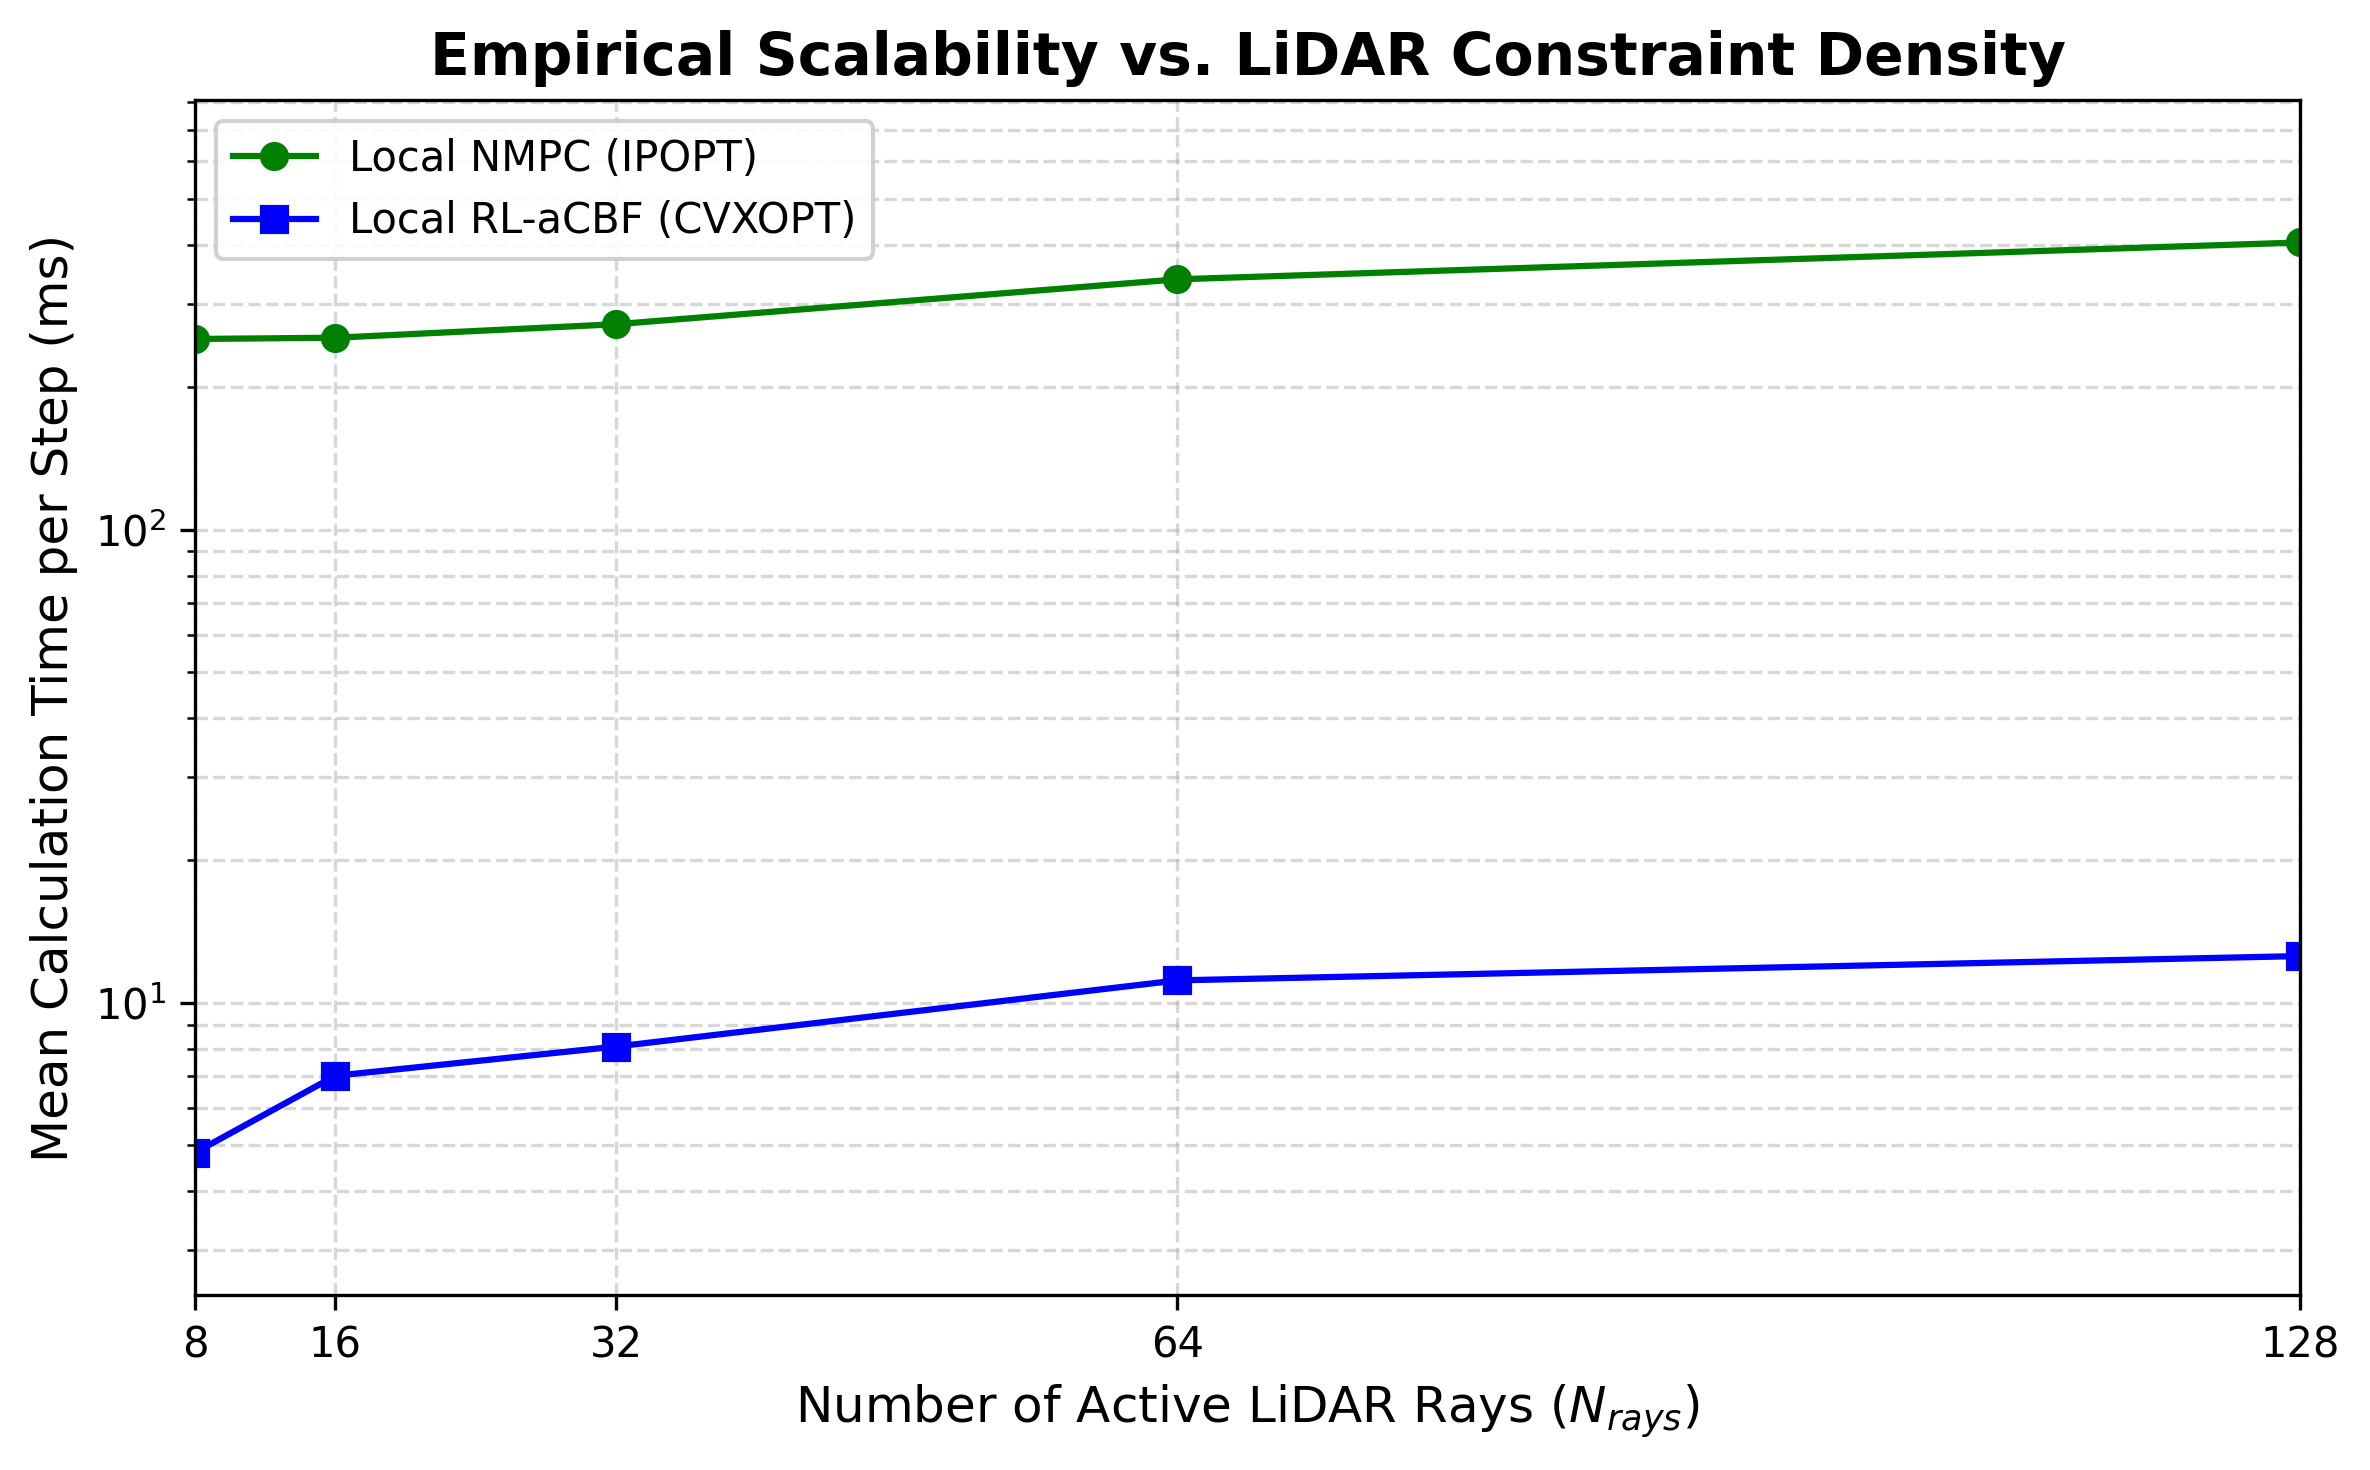

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt


class DummyState:
    def __init__(self):
        self.x, self.y, self.phi = 400.0, 200.0, 0.0
        self.xDot, self.yDot, self.phiDot = 5.0, 0.0, 0.0

state_bench = DummyState()
target_pos = np.array([500.0, 250.0])
u_nom_bench = np.array([1.8 * 0.18 * 9.81, 0.0])

n_rays_list = [8, 16, 32, 64, 128]

cbf_empirical_times = []
nmpc_empirical_times = []

print("--- Starting Empirical Benchmark (This may take a few minutes) ---")

for n in n_rays_list:
    print(f"\nBenchmarking N_rays = {n}")
    
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    dists = np.random.uniform(50.0, 150.0, n)
    
    cbf = LocalAdaptiveCBFQPController(m_nom=0.18, gamma=0.8, alpha=0.8)
    
    for _ in range(5):
        cbf.filter_action(u_nom_bench, state_bench, dists, angles)
        
    start_cbf = time.perf_counter()
    cbf_iters = 300
    for _ in range(cbf_iters):
        cbf.filter_action(u_nom_bench, state_bench, dists, angles)
    end_cbf = time.perf_counter()
    
    avg_cbf = ((end_cbf - start_cbf) / cbf_iters) * 1000
    cbf_empirical_times.append(avg_cbf)
    print(f"  -> CBF Mean Time:  {avg_cbf:.4f} ms")
    
    nmpc = LocalLiDAR_NMPC(m=0.18, J=1.5e-4, dt=0.05, N=62, n_rays=n)
    
    nmpc.compute_action(state_bench, target_pos, dists, angles)
    
    start_nmpc = time.perf_counter()
    nmpc_iters = 300 
    for _ in range(nmpc_iters):
        nmpc.compute_action(state_bench, target_pos, dists, angles)
    end_nmpc = time.perf_counter()
    
    avg_nmpc = ((end_nmpc - start_nmpc) / nmpc_iters) * 1000
    nmpc_empirical_times.append(avg_nmpc)
    print(f"  -> NMPC Mean Time: {avg_nmpc:.4f} ms")

print("\n--- Benchmarking Complete! Generating Plot... ---")


plt.figure(figsize=(8, 5), dpi=300)

plt.plot(n_rays_list, nmpc_empirical_times, 'g-o', marker='o', label='Local NMPC (IPOPT)')
plt.plot(n_rays_list, cbf_empirical_times, 'b-s', marker='s', label='Local RL-aCBF (CVXOPT)')

plt.title('Empirical Scalability vs. LiDAR Constraint Density', fontsize=14, fontweight='bold')
plt.xlabel('Number of Active LiDAR Rays ($N_{rays}$)', fontsize=12)
plt.ylabel('Mean Calculation Time per Step (ms)', fontsize=12)

plt.xlim(8, 128)
plt.xticks(n_rays_list)
plt.yscale('log')

plt.ylim(min(cbf_empirical_times) * 0.5, max(nmpc_empirical_times) * 2.0)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('Empirical_Scalability_Analysis.pdf', format='pdf', bbox_inches='tight')
plt.show()


C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\2452254720.py:10: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g-o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(n_rays_list, nmpc_empirical_times, 'g-o', marker='o', label='Local NMPC (IPOPT)')
C:\Users\Nia Touko\AppData\Local\Temp\ipykernel_2128\2452254720.py:11: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b-s" (-> marker='s'). The keyword argument will take precedence.
  plt.plot(n_rays_list, cbf_empirical_times, 'b-s', marker='s', label='Local RL-aCBF (CVXOPT)')


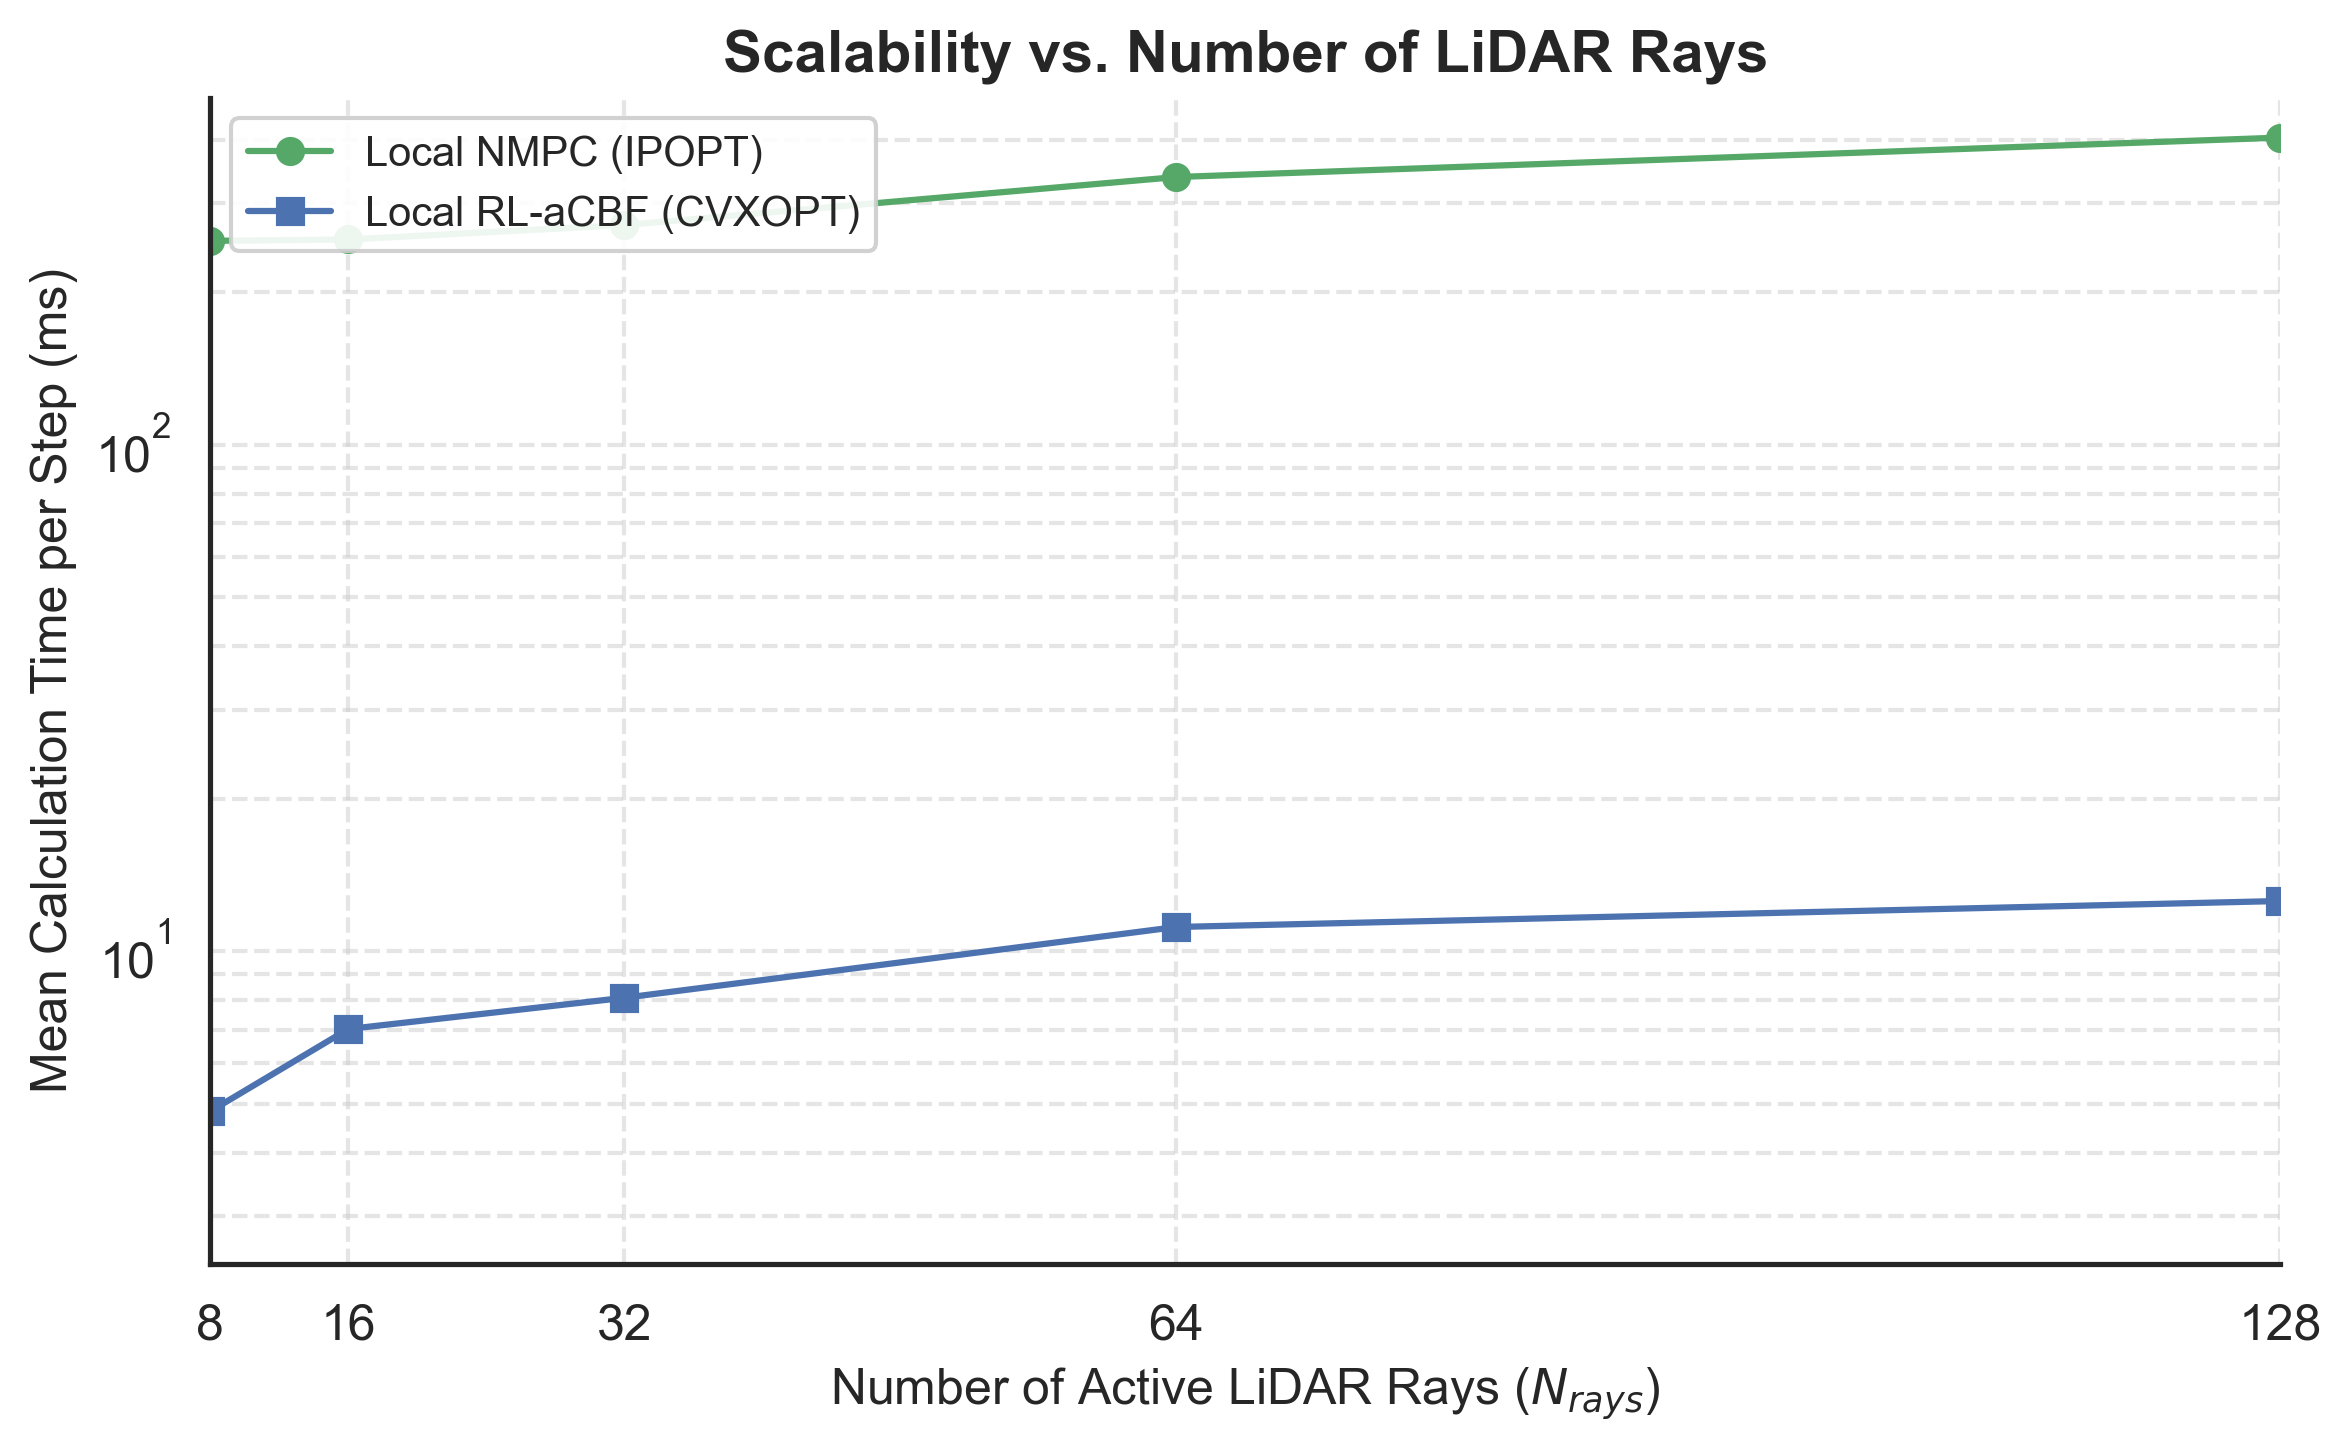

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="white")

plt.figure(figsize=(8, 5), dpi=300)
ax = plt.gca()

plt.plot(n_rays_list, nmpc_empirical_times, 'g-o', marker='o', label='Local NMPC (IPOPT)')
plt.plot(n_rays_list, cbf_empirical_times, 'b-s', marker='s', label='Local RL-aCBF (CVXOPT)')

plt.title('Scalability vs. Number of LiDAR Rays', fontsize=14, fontweight='bold')
plt.xlabel('Number of Active LiDAR Rays ($N_{rays}$)', fontsize=12)
plt.ylabel('Mean Calculation Time per Step (ms)', fontsize=12)

plt.xlim(8, 128)
plt.xticks(n_rays_list)
plt.yscale('log')

plt.ylim(min(cbf_empirical_times) * 0.5, max(nmpc_empirical_times) * 1.2)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('Empirical_Scalability_Analysis.pdf', format='pdf', bbox_inches='tight')
plt.show()





In [21]:
class DynamicObstacle:
    def __init__(self, x, y, r, vx=0.0, vy=0.0):
        self.c = np.array([float(x), float(y)])
        self.r = r
        self.v = np.array([float(vx), float(vy)])
        
    def update(self, dt, x_bounds=(0, 800), y_bounds=(0, 450)):
        self.c += self.v * dt
        
        if self.c[0] - self.r <= x_bounds[0] or self.c[0] + self.r >= x_bounds[1]:
            self.v[0] *= -1
        if self.c[1] - self.r <= y_bounds[0] or self.c[1] + self.r >= y_bounds[1]:
            self.v[1] *= -1

    def __call__(self):
        return self.c, self.r
    
    


In [ ]:
import numpy as np
import pandas as pd
import copy
import time
from IPython.display import display

def generate_random_scenario(level):
    while True:
        start = np.random.uniform([30, 50], [150, 400])
        goal = np.random.uniform([650, 50], [770, 400])
        if np.linalg.norm(goal - start) > 400:
            break
            
    num_obs = np.random.randint(4, 8)
    obstacles = []
    for _ in range(num_obs):
        while True:
            c = np.random.uniform([200, 50], [600, 400])
            r = np.random.uniform(30, 75)
            dist_to_start = np.linalg.norm(c - start)
            dist_to_goal = np.linalg.norm(c - goal)
            if dist_to_start > r + 40 and dist_to_goal > r + 40:
                break
        
        vx, vy = 0.0, 0.0
        if level >= 2:
            vx = np.random.uniform(-15.0, 15.0)
            vy = np.random.uniform(-15.0, 15.0)
            
        obstacles.append(DynamicObstacle(c[0], c[1], r, vx, vy))
        
    if level == 3:
        base_mass = np.random.uniform(0.15, 0.25)
        mass_shift = np.random.uniform(0.05, 0.15)
        def mass_func(t):
            return base_mass if t < 8else base_mass + mass_shift
            
        wind_x = np.random.uniform(-0.25, 0.25)
        wind_y = np.random.uniform(-0.25, 0.25)
        def wind_func(t):
            alpha = 1/ (1+ np.exp(-4* (t - 8.0))) 
            return np.array([0.0, 0.0]) * (1 - alpha) + np.array([wind_x, wind_y]) * alpha
    else:
        mass_func = lambda t: 0.18
        wind_func = lambda t: np.array([0.0, 0.0])
        
    return {
        'start': start.tolist(),
        'goal': goal.tolist(),
        'obstacles': obstacles,
        'mass_func': mass_func,
        'wind_func': wind_func
    }


def run_custom_scenario(controller_type, scenario_dict, model_rl=None):
    env = TimeOptimalNavEnv()
    start, goal = scenario_dict['start'], scenario_dict['goal']
    active_obstacles = [copy.deepcopy(o) for o in scenario_dict['obstacles']]
    
    cbf, nmpc, vector_field = None, None, None
    n_lidar_rays = 32
    
    if controller_type == "RL-CBF": 
        cbf = CBFQPController(nominal_controller=None, m=0.18, J=env.quad.J, gamma=0.8, alpha=0.8)
    elif controller_type == "RL-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
    elif controller_type == "APF-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
        vector_field = GoalVectorFieldController(m=0.18)
    elif controller_type == "NMPC": 
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)
    elif controller_type == "NMPC-CBF": 
        cbf = CBFQPController(nominal_controller=None, m=0.18, J=env.quad.J, gamma=0.8, alpha=0.8)
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)
    elif controller_type == "NMPC-aCBF": 
        cbf = LocalAdaptiveCBFQPController(m_nom=0.18, J=env.quad.J, gamma=0.6, alpha=0.7)
        nmpc = LocalLiDAR_NMPC(m=0.18, J=env.quad.J, dt=env.dt, N=80, n_rays=n_lidar_rays)

    obs, _ = env.reset()
    env.quad.state = X(np.array([start[0], start[1], 0, 0, 0, 0]))
    env.goal = np.array(goal)
    env.prev_dist = np.linalg.norm(env.goal - np.array(start))
    obs = env._get_obs()
    
    done, truncated, steps, crashed = False, False, 0, False
    start_calc_time = time.time()
    
    while not (done or truncated):
        t = steps * env.dt
        current_true_mass = scenario_dict['mass_func'](t)
        current_wind = scenario_dict['wind_func'](t)
        env.quad.m = current_true_mass
        state = env.quad.state
        
        dists, angles = get_lidar(state, active_obstacles, n_lidar=n_lidar_rays)
        gym_action = np.zeros(2)
        u1_applied = 0.0

        if controller_type in ["RL Nominal", "RL-CBF", "RL-aCBF"]:
            action_sac, _ = model_rl.predict(obs, deterministic=True)
            est_mass = (1/ cbf.theta_m) if controller_type == "RL-aCBF" else 0.18
            F_nom = ((action_sac[0] + 1) / 2) * (1.8 * est_mass * 9.81)
            F_nom = np.clip(F_nom, 0, 1.8 * 0.18 * 9.81)
            M_nom = action_sac[1] * 0.02
            u_nom = np.array([F_nom, M_nom], dtype=np.float64)
            
            u_safe = u_nom if controller_type == "RL Nominal" else cbf.filter_action(u_nom, state, dists, angles)
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = ((gym_action[0] + 1) / 2) * (1.8 * current_true_mass * 9.81)

        elif controller_type == "APF-aCBF": 
            u_nom = vector_field.get_nominal_action(state, goal)
            if np.any(np.isnan(u_nom)): u_nom = np.array([0.18 * 9.81, 0.0])
            u_safe = cbf.filter_action(u_nom, state, dists, angles)
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = u_safe[0]

        elif controller_type == "NMPC":
            target = np.array([goal[0], goal[1]])
            u_opt = nmpc.compute_action(state, target, dists, angles)
            gym_action[0] = (float(u_opt[0]) / (1.8 * current_true_mass * 9.81)) * 2 - 1
            gym_action[1] = float(u_opt[1]) / 0.02
            u1_applied = float(u_opt[0])
            
        elif controller_type in ["NMPC-CBF", "NMPC-aCBF"]: 
            target = np.array([goal[0], goal[1]])
            u_nom = nmpc.compute_action(state, target, dists, angles)
            u_safe = cbf.filter_action(u_nom, state, dists, angles)
            gym_action[0] = (u_safe[0] / (1.8 * current_true_mass * 9.81)) * 2 - 1 
            gym_action[1] = u_safe[1] / 0.02
            u1_applied = u_safe[0]

        gym_action = np.clip(gym_action, -1.0, 1.0)
        vx_old, vy_old, phi_old = state.xDot, state.yDot, state.phi
        
        obs, reward, done, truncated, info = env.step(gym_action, wind_force=current_wind)
        
        for obs_obj in active_obstacles:
            if hasattr(obs_obj, 'update'): obs_obj.update(env.dt)
                
        if controller_type in ["RL-aCBF", "NMPC-aCBF", "APF-aCBF"]:
            true_ax = (env.quad.state.xDot - vx_old) / env.dt
            true_ay = (env.quad.state.yDot - vy_old) / env.dt
            cbf.adapt(phi_old, u1_applied, true_ax, true_ay, env.dt, vx_old, vy_old)
            
        current_pos = np.array([env.quad.state.x, env.quad.state.y])
        for obs_obj in active_obstacles:
            if np.linalg.norm(current_pos - obs_obj.c) <= obs_obj.r:
                crashed = True
                done = True
                break
                
        steps += 1
        
    calc_time = time.time() - start_calc_time
    is_success = info.get('is_success', False)
    if crashed: is_success = False
        
    return is_success, crashed, steps * env.dt, calc_time


def run_benchmark(n_valid_scenarios_per_level, controllers, model_rl):
    levels = {
        1: "Level 1: Static / Nominal",
        2: "Level 2: Dynamic / Nominal",
        3: "Level 3: Dynamic / Uncertainty"
    }
    
    all_results = []
    
    for level, level_name in levels.items():
        print(f"Starting {level_name} Benchmark")
        
        valid_scenarios_found = 0
        total_attempts = 0
        
        while valid_scenarios_found < n_valid_scenarios_per_level:
            total_attempts += 1
            scenario = generate_random_scenario(level)
            
            scenario_results = {}
            any_controller_succeeded = False
            
            for ctrl in controllers:
                success, crashed, f_time, c_time = run_custom_scenario(ctrl, scenario, model_rl)
                scenario_results[ctrl] = {
                    'Success': success,
                    'Crashed': crashed,
                    'Timeout': (not success and not crashed),
                    'FlightTime': f_time,
                    'CalcTime': c_time
                }
                if success:
                    any_controller_succeeded = True
            
            if any_controller_succeeded:
                valid_scenarios_found += 1
                print(f"[{level_name}] Scenario {valid_scenarios_found}/{n_valid_scenarios_per_level} completed successfully.")
                
                for ctrl in controllers:
                    res = scenario_results[ctrl]
                    all_results.append({
                        'Level': level,
                        'Controller': ctrl,
                        'Success': 1 if res['Success'] else 0,
                        'Crash': 1 if res['Crashed'] else 0,
                        'Timeout': 1 if res['Timeout'] else 0,
                        'Flight Time (s)': res['FlightTime'] if res['Success'] else np.nan, 
                        'Calc Time (s)': res['CalcTime']
                    })
            else:
                pass 
                
        print(f"Yield: Found {n_valid_scenarios_per_level} valid scenarios in {total_attempts} attempts.")
        
    df = pd.DataFrame(all_results)
    
    summary = df.groupby(['Level', 'Controller']).agg(
        Success_Rate=('Success', lambda x: x.mean() * 100),
        Crash_Rate=('Crash', lambda x: x.mean() * 100),
        Timeout_Rate=('Timeout', lambda x: x.mean() * 100),
        Avg_Flight_Time=('Flight Time (s)', 'mean'),
        Avg_Calc_Time=('Calc Time (s)', 'mean')
    ).reset_index()
    
    summary['Success_Rate'] = summary['Success_Rate'].map('{:.1f}%'.format)
    summary['Crash_Rate'] = summary['Crash_Rate'].map('{:.1f}%'.format)
    summary['Timeout_Rate'] = summary['Timeout_Rate'].map('{:.1f}%'.format)
    summary['Avg_Flight_Time'] = summary['Avg_Flight_Time'].map('{:.2f}s'.format)
    summary['Avg_Calc_Time'] = summary['Avg_Calc_Time'].map('{:.3f}s'.format)
    
    return summary

controllers_to_test = ["RL Nominal", "RL-CBF", "RL-aCBF", "APF-aCBF", "NMPC", "NMPC-aCBF"]

final_benchmark_table = run_benchmark(n_valid_scenarios_per_level=25, 
                                      controllers=controllers_to_test, 
                                      model_rl=model)

print("\n\nFINAL BENCHMARK RESULTS")
display(final_benchmark_table)

Starting Level 1: Static / Nominal Benchmark
[Level 1: Static / Nominal] Scenario 1/25 completed successfully.
[Level 1: Static / Nominal] Scenario 2/25 completed successfully.
[Level 1: Static / Nominal] Scenario 3/25 completed successfully.
[Level 1: Static / Nominal] Scenario 4/25 completed successfully.
[Level 1: Static / Nominal] Scenario 5/25 completed successfully.
[Level 1: Static / Nominal] Scenario 6/25 completed successfully.
[Level 1: Static / Nominal] Scenario 7/25 completed successfully.
[Level 1: Static / Nominal] Scenario 8/25 completed successfully.
[Level 1: Static / Nominal] Scenario 9/25 completed successfully.
[Level 1: Static / Nominal] Scenario 10/25 completed successfully.
[Level 1: Static / Nominal] Scenario 11/25 completed successfully.
[Level 1: Static / Nominal] Scenario 12/25 completed successfully.
[Level 1: Static / Nominal] Scenario 13/25 completed successfully.
[Level 1: Static / Nominal] Scenario 14/25 completed successfully.
[Level 1: Static / Nominal

,Level,Controller,Success_Rate,Crash_Rate,Timeout_Rate,Avg_Flight_Time,Avg_Calc_Time
0,1,APF-aCBF,48.00%,0.00%,52.00%,55.76s,24.781s
1,1,NMPC,44.00%,56.00%,0.00%,18.55s,19.138s
2,1,NMPC-aCBF,80.00%,4.00%,16.00%,34.85s,103.510s
3,1,RL Nominal,40.00%,56.00%,4.00%,27.03s,1.807s
4,1,RL-CBF,92.00%,0.00%,8.00%,46.78s,20.822s
5,1,RL-aCBF,90.00%,0.00%,10.00%,43.57s,21.452s
6,2,APF-aCBF,36.00%,64.00%,0.00%,50.76s,9.365s
7,2,NMPC,24.00%,76.00%,0.00%,17.58s,15.843s
8,2,NMPC-aCBF,68.00%,32.00%,0.00%,36.16s,68.251s
9,2,RL Nominal,8.00%,88.00%,4.00%,24.36s,1.018s
